# Моделювання газу твердих сфер

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from random import random

Константи

In [2]:
k = 1.38e-23

Вхідні дані

In [3]:
S = np.pi * 1e-18
H = 1e-9
N = 500
R = 53e-12
M = 1.67e-27
T = 100
# G = 9.8
G = 5e15
C = 0

Змінні та функції для зручності

In [4]:
# Діаметр основи циліднра
D = 2 * np.sqrt(S / np.pi)

# Випадковий одиничний вектор
def random_k():
    while True:
        k = np.array([random() - 0.5, random() - 0.5, random() - 0.5])
        norm = np.linalg.norm(k)
        if norm > 1e-10:
            return k / norm

In [5]:
# Кінетична енергія від швидкості
def K(v):
    return M*v**2/2

def PT(p):
    # return M*G*p[-1]
    return M*G*(p[-1])

# Швидкість від кінетичної енергії
def v(K):
    return np.sqrt(2*K/M)

In [6]:
# Відбиття частинки від перешкоди
def update_velocity_on_obstacle(p, v):
    return v - 2 * p @ v * p 

In [7]:
# Закон збереження імпульсу
def update_velocities(p1, p2, v1, v2):
    p = (p1 - p2) / np.linalg.norm(p1 - p2)
    d = p @ (v1 -  v2) * p
    v1new = v1 - d
    v2new = v2 + d
    return v1new, v2new

Генерування положення кульок (в межах посудини) і їхні швидкості випадковим чином, але так, 
щоб сума їхніх кінетичних енергії була рівна $3NkT/2$ (N--кількість частинок, T--температура, k--стала Больцмана)

In [8]:
total_enegry = 3 * N * k * T / 2 
energies = np.array([(random()) for _ in range(N)])
energies = energies / sum(energies) * total_enegry

In [9]:
def initialize_non_overlapping_positions(N, R, D, H, max_attempts=10000):
    positions = []
    attempts = 0
    while len(positions) < N and attempts < max_attempts:
        attempts += 1
        candidate = np.array([
            (random() - 0.5) * (D - 2 * R),
            (random() - 0.5) * (D - 2 * R),
            (random() - 0.5) * (H - 2 * R)
        ])
        if all(np.linalg.norm(candidate - p) > 2 * R for p in positions):
            positions.append(candidate)
    if len(positions) < N:
        raise RuntimeError(f"Не вдалося ініціалізувати всі {N} частинки без перетинів.")
    return np.array(positions)

In [10]:
# initial_positions = np.array([[(random() - 0.5) * (D-10*R), (random() - 0.5) * (D-10*R), (random() - 0.5) * (H-10*R)] for _ in range(N)])
initial_positions = initialize_non_overlapping_positions(N, R, D,H)
initial_velocities = np.array([random_k() * v(K) for K in energies])

N = 2
initial_positions = np.array([[-1e-6, 0, 0],[1e-6, 0, 0]])
initial_velocities = np.array([[1000, 0, 0], [-1000, 0, 0]])

Оновлення позицій 

In [11]:
def new_positions(positions, velocities, dt):
    return positions + velocities * dt

Перевірка на зіткнення

In [12]:
def detect_collisions(positions):
    collisions_matrix = np.zeros((N, N))
    # for i, p1 in enumerate(positions[:-1]):
    #     for j, p2 in enumerate(positions[i+1:]):
    #         if np.linalg.norm(positions[i] - positions[i + j+1]) <= 2*R:
    #             collisions_matrix[i][i + j+1] = 1
    #             collisions_matrix[i + j+1][i] = 1
    for i in range(N):
        for j in range(i + 1, N):
            if np.linalg.norm(positions[i] - positions[j]) <= 2 * R:
                collisions_matrix[i][j] = 1
                collisions_matrix[j][i] = 1
    return collisions_matrix

In [13]:
def detect_collisions(positions):
    global C
    cell_size = 2 * R
    cell_map = {}
    collisions = np.zeros((N, N))

    def cell_key(pos):
        return tuple((pos // cell_size).astype(int))

    for i, pos in enumerate(positions):
        key = cell_key(pos)
        if key not in cell_map:
            cell_map[key] = []
        cell_map[key].append(i)

    # перевіряємо лише частинки з поточної та суміжних клітинок
    for key, indices in cell_map.items():
        neighbor_offsets = [
            (dx, dy, dz)
            for dx in [-1, 0, 1]
            for dy in [-1, 0, 1]
            for dz in [-1, 0, 1]
        ]
        for offset in neighbor_offsets:
            neighbor_key = tuple(np.add(key, offset))
            if neighbor_key in cell_map:
                for i in indices:
                    for j in cell_map[neighbor_key]:
                        if i < j and np.linalg.norm(positions[i] - positions[j]) <= 2 * R:
                            collisions[i][j] = 1
                            collisions[j][i] = 1
                            C += 1
    return collisions

Оновлення швидкостей

In [14]:
from copy import deepcopy

In [15]:
def process_obstacles(positions, velocities):
    new_velocities = deepcopy(velocities)
    for i, pos in enumerate(positions):
        # Бічні стінки
        if np.linalg.norm(np.array(pos[:-1])) >= D / 2 - R:
            p = np.array([
                -pos[0],
                -pos[1],
                0
            ])
            p /= np.linalg.norm(p)
            new_velocities[i] = update_velocity_on_obstacle(p, new_velocities[i])
            # print(f"particle {i} hit obstacle; normal = {p}, old_v = {velocities[i]}, new_v = {new_velocities[i]}")
        # Кришки
        if abs(pos[2]) >= H / 2 - R:
            p = np.array([
                0,
                0,
                -pos[2]
            ])
            p /= np.linalg.norm(p)
            new_velocities[i] = update_velocity_on_obstacle(p, new_velocities[i])

            # print(f"particle {i} hit obstacle; normal = {p}, old_v = {velocities[i]}, new_v = {new_velocities[i]}")
    return new_velocities


In [16]:
def gravity(v,dt):
    return v + np.array([0,0,-G])*dt

In [17]:
def new_velocities(positions, collisions_matrix, velocities, dt):
    new_velocities = deepcopy(velocities)
    for i in range(N):
        for j in range(N): 
            if collisions_matrix[i][j]:
                new = update_velocities(
                    positions[i],
                    positions[j],
                    new_velocities[i],
                    new_velocities[j])
                # print(f"new: {new}")
                # quit()
                new_velocities[i], new_velocities[j] = new
    # return new_velocities
    v = process_obstacles(positions, new_velocities)
    return gravity(v, dt)

### Cимуляція

Параметри симуляції

In [18]:
simulation_time = 1e-11

Симуляція

In [19]:
t = 0
positions = {0: initial_positions}
velocities = {0: initial_velocities}

In [ ]:
while t < simulation_time:
   current_positions = positions[t]
   current_velocities = velocities[t]
   dt = R / 4 / max(np.linalg.norm(v) for v in current_velocities)
   updated_positions = new_positions(current_positions, current_velocities, dt)
   collisions_matrix = detect_collisions(updated_positions)
   updated_velocities = new_velocities(updated_positions, collisions_matrix, current_velocities, dt)
   t += dt
   positions[t] = updated_positions 
   velocities[t] = updated_velocities
   print(f"t: {t}")
   print(1/dt/4*R)
   # print(f"positions: {updated_positions}")
   # print(f"velocities: {updated_velocities}")
   print(f"collisions: {C}")

t: 5.963939470563973e-15
2221.685861400439
collisions: 12
t: 1.1906290465932768e-14
2229.757213992654
collisions: 36
t: 1.7802952335646976e-14
2247.0340495617024
collisions: 82
t: 2.3647827664515994e-14
2266.9431347073523
collisions: 142
t: 2.9439417892674176e-14
2287.7999785930497
collisions: 218
t: 3.492248128863235e-14
2416.5323366071607
collisions: 307
t: 3.974281388189596e-14
2748.772982701816
collisions: 403
t: 4.401047883365782e-14
3104.7423239094464
collisions: 509
t: 4.890076231263772e-14
2709.454381725107
collisions: 622
t: 5.401075013545536e-14
2592.961169268298
collisions: 741
t: 5.862109793183383e-14
2873.969727491745
collisions: 863
t: 6.266752734944879e-14
3274.4918130339697
collisions: 992
t: 6.665233804599874e-14
3325.12658919327
collisions: 1120
t: 7.065501713112029e-14
3310.2828676053223
collisions: 1249
t: 7.502732266686411e-14
3030.43780716617
collisions: 1376
t: 7.962208189605677e-14
2883.7201992688833
collisions: 1506
t: 8.413248672078951e-14
2937.652054499368
co

### а) графік розподілу частинок по швидкостях (розподіл Максвела)

##### За весь період

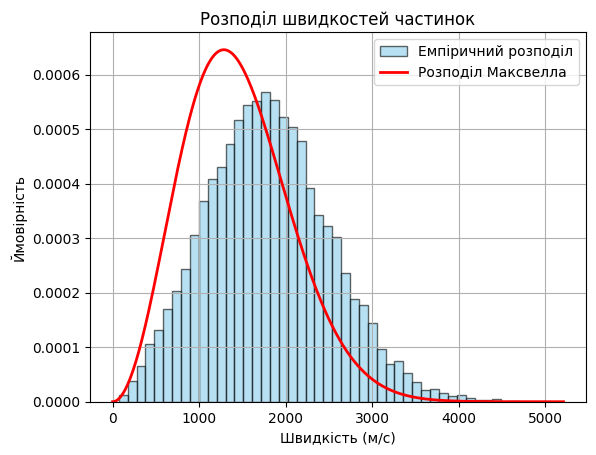

In [ ]:

from scipy.stats import maxwell

# Витягуємо всі швидкості за всі моменти часу
all_velocities = [v for vs in velocities.values() for v in vs]
speeds = [np.linalg.norm(v) for v in all_velocities]

# Побудова гістограми
count, bins, _ = plt.hist(speeds, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Емпіричний розподіл')

# Теоретичний розподіл Максвелла
x = np.linspace(0, max(speeds), 500)

# Обчислення масштабу для розподілу Максвелла
scale = np.sqrt(k * T / M)

# Побудова аналітичної кривої
plt.plot(x, maxwell.pdf(x, scale=scale), 'r-', linewidth=2, label='Розподіл Максвелла')

# Оформлення графіку
plt.title('Розподіл швидкостей частинок')
plt.xlabel('Швидкість (м/с)')
plt.ylabel('Ймовірність')
plt.legend()
plt.grid(True)
plt.show()


##### В останній момент часу

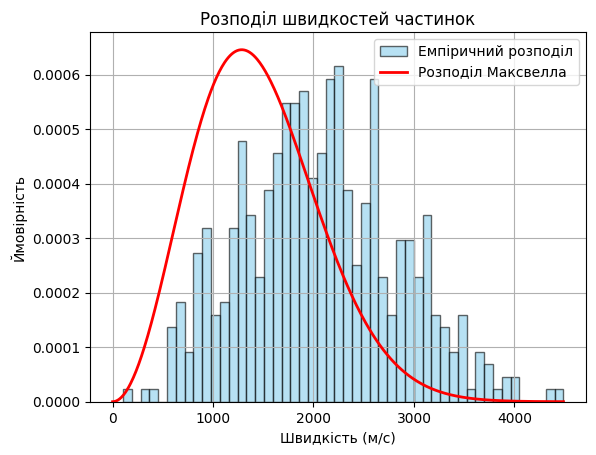

In [ ]:
# Витягуємо всі швидкості з останнього моменту часу
final_velocities = list(velocities.values())[-1]

# Обчислюємо модулі (швидкості)
speeds = [np.linalg.norm(v) for v in final_velocities]

# Побудова гістограми
count, bins, _ = plt.hist(speeds, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Емпіричний розподіл')

# Теоретичний розподіл Максвелла
x = np.linspace(0, max(speeds), 500)

# Обчислення масштабу для розподілу Максвелла
scale = np.sqrt(k * T / M)

# Побудова аналітичної кривої
plt.plot(x, maxwell.pdf(x, scale=scale), 'r-', linewidth=2, label='Розподіл Максвелла')

# Оформлення графіку
plt.title('Розподіл швидкостей частинок')
plt.xlabel('Швидкість (м/с)')
plt.ylabel('Ймовірність')
plt.legend()
plt.grid(True)
plt.show()

##### Розподіл за енергіями (розподіл Больцмана)

/tmp/ipykernel_63986/1115473371.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P /= np.trapz(P, E)  # нормалізуємо, щоб площа під кривою була 1


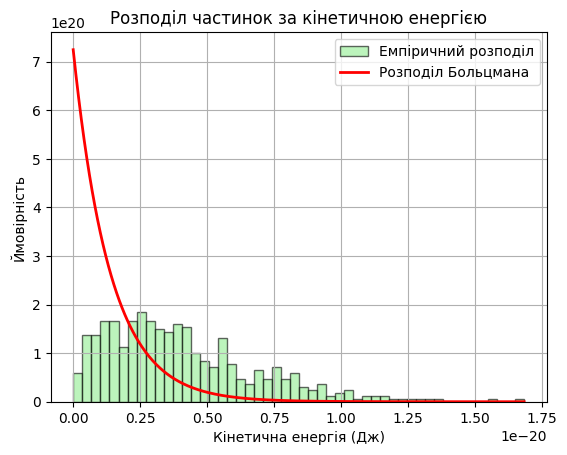

In [ ]:

# Витягуємо всі кінетичні енергії з останнього моменту часу
final_velocities = list(velocities.values())[-1]
energies_sim = [K(np.linalg.norm(v)) for v in final_velocities]  # K(v) вже задана у тебе

# Гістограма енергій
count, bins, _ = plt.hist(energies_sim, bins=50, density=True, alpha=0.6, color='lightgreen', edgecolor='black', label='Емпіричний розподіл')

# Теоретична крива Больцмана
E = np.linspace(0, max(energies_sim), 500)
P = np.exp(-E / (k * T))
P /= np.trapz(P, E)  # нормалізуємо, щоб площа під кривою була 1

# Побудова теоретичної кривої
plt.plot(E, P, 'r-', label='Розподіл Больцмана', linewidth=2)

# Оформлення графіку
plt.title('Розподіл частинок за кінетичною енергією')
plt.xlabel('Кінетична енергія (Дж)')
plt.ylabel('Ймовірність')
plt.legend()
plt.grid(True)
plt.show()

### Розподіл тиску за висотою (теж розподіл Больцмана, в останній момент часу).

In [ ]:
number_of_heights = 100

last_positions = positions[t]
last_velocities = velocities[t]
ordered_position_velocity_pairs = sorted(zip(last_positions, last_velocities), key=lambda x: x[0][-1])  # Сортує за B
sorted_positions, sorted_velocities,  = zip(*ordered_position_velocity_pairs)  # Розпаковуємо назад


intervals = []
height = - H / 2
index = 0
while height <= H:
    if index == N:
        break
    height += H / number_of_heights
    intervals.append(list())
    while sorted_positions[index][-1] < height:
        intervals[-1].append(index)
        index += 1
        if index == N:
            break


print(height)
print(intervals)
print(len(intervals))
print(index)
    

3.800000000000004e-10
[[], [], [], [], [0, 1, 2, 3, 4, 5, 6, 7, 8], [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32], [33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46], [47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65], [66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84], [85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98], [99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123], [124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139], [140, 141, 142, 143, 144, 145, 146, 147, 148, 149], [150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162], [163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178], [179, 180, 181, 182, 183, 184, 185, 186, 187, 188], [189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201], [202, 203, 204, 205, 206, 207, 208,

In [ ]:
def mean_pressure(interval):
    # p = 2 / i / V * E
    p = 0
    for index in interval:
        p += K(np.linalg.norm(sorted_velocities[index]))
    p *= 2 / 3 / H * number_of_heights / np.pi / D**2 * 4
    return p 

In [ ]:
def initial_pressure(N, m, T, D, H, k=1.38e-23, g=9.81):
    A = np.pi * D**2 / 4
    P_avg = N * k * T / (A * H)
    exp_term = 1 - np.exp(-m * g * H / (k * T))
    P0 = P_avg * H * m * g / (k * T * exp_term)
    return P0

88
[-5.00000000e-10 -4.89898990e-10 -4.79797980e-10 -4.69696970e-10
 -4.59595960e-10 -4.49494949e-10 -4.39393939e-10 -4.29292929e-10
 -4.19191919e-10 -4.09090909e-10 -3.98989899e-10 -3.88888889e-10
 -3.78787879e-10 -3.68686869e-10 -3.58585859e-10 -3.48484848e-10
 -3.38383838e-10 -3.28282828e-10 -3.18181818e-10 -3.08080808e-10
 -2.97979798e-10 -2.87878788e-10 -2.77777778e-10 -2.67676768e-10
 -2.57575758e-10 -2.47474747e-10 -2.37373737e-10 -2.27272727e-10
 -2.17171717e-10 -2.07070707e-10 -1.96969697e-10 -1.86868687e-10
 -1.76767677e-10 -1.66666667e-10 -1.56565657e-10 -1.46464646e-10
 -1.36363636e-10 -1.26262626e-10 -1.16161616e-10 -1.06060606e-10
 -9.59595960e-11 -8.58585859e-11 -7.57575758e-11 -6.56565657e-11
 -5.55555556e-11 -4.54545455e-11 -3.53535354e-11 -2.52525253e-11
 -1.51515152e-11 -5.05050505e-12  5.05050505e-12  1.51515152e-11
  2.52525253e-11  3.53535354e-11  4.54545455e-11  5.55555556e-11
  6.56565657e-11  7.57575758e-11  8.58585859e-11  9.59595960e-11
  1.06060606e-10  1.16

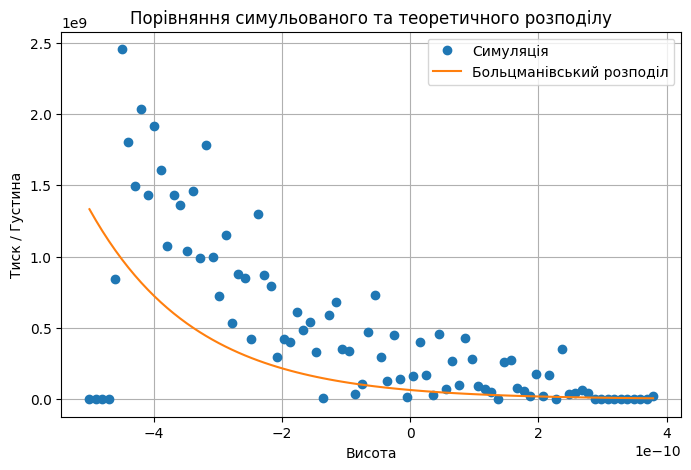

In [ ]:
heights = np.linspace(-H / 2, H / 2, number_of_heights)[:len(intervals)]
print(len(heights))
print(heights)
pressures = [mean_pressure(i) for i in intervals]
print(len(pressures))
print(pressures)


# Припустимо, ці параметри задані:
P0 = initial_pressure(N, M, T, D, H, k, G)   # початковий тиск (умовна одиниця)

# Висоти
# Теоретичний тиск
P_boltzmann = P0 * np.exp(-(M * G * (heights + H / 2 )  )  / (k * T))

# Побудова графіка
plt.figure(figsize=(8, 5))
plt.plot(heights, pressures, label='Симуляція', marker='o', linestyle='None')
plt.plot(heights, P_boltzmann, label='Больцманівський розподіл', linestyle='-')
plt.xlabel('Висота')
plt.ylabel('Тиск / Густина')
plt.title('Порівняння симульованого та теоретичного розподілу')
plt.legend()
plt.grid(True)
plt.show()
 

## Поправка на зміну температури

In [ ]:
positions[t]

array([[-5.57877923e-10, -3.85919514e-10, -4.44372661e-10],
       [ 6.24670059e-10, -4.34076778e-10, -1.20617594e-10],
       [-2.04952646e-10, -6.80632092e-10, -1.74680553e-10],
       ...,
       [ 1.27449598e-10, -7.35150148e-10, -2.29883094e-10],
       [ 8.92071547e-10, -7.30052901e-10, -1.21780026e-10],
       [ 7.01410952e-10,  4.06940124e-10, -2.94696815e-10]],
      shape=(500, 3))

In [ ]:
def Tdot(T, positions):
    return T - 2 / 3 / N / k * sum([PT(p) for p in positions[t]])

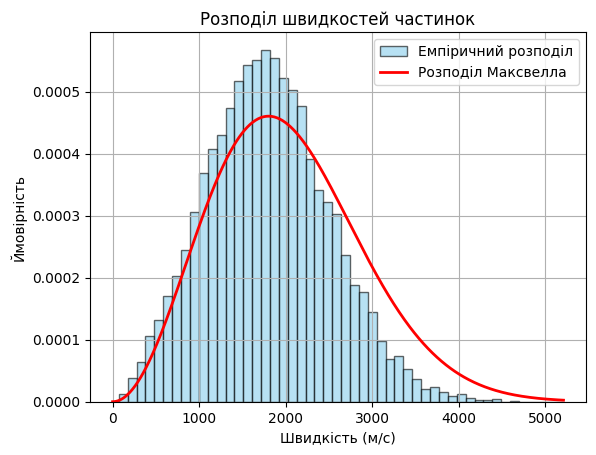

In [ ]:

from scipy.stats import maxwell

# Витягуємо всі швидкості за всі моменти часу
all_velocities = [v for vs in velocities.values() for v in vs]
speeds = [np.linalg.norm(v) for v in all_velocities]

# Побудова гістограми
count, bins, _ = plt.hist(speeds, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Емпіричний розподіл')

# Теоретичний розподіл Максвелла
x = np.linspace(0, max(speeds), 500)

# Обчислення масштабу для розподілу Максвелла
scale = np.sqrt(k * Tdot(T, positions) / M)

# Побудова аналітичної кривої
plt.plot(x, maxwell.pdf(x, scale=scale), 'r-', linewidth=2, label='Розподіл Максвелла')

# Оформлення графіку
plt.title('Розподіл швидкостей частинок')
plt.xlabel('Швидкість (м/с)')
plt.ylabel('Ймовірність')
plt.legend()
plt.grid(True)
plt.show()


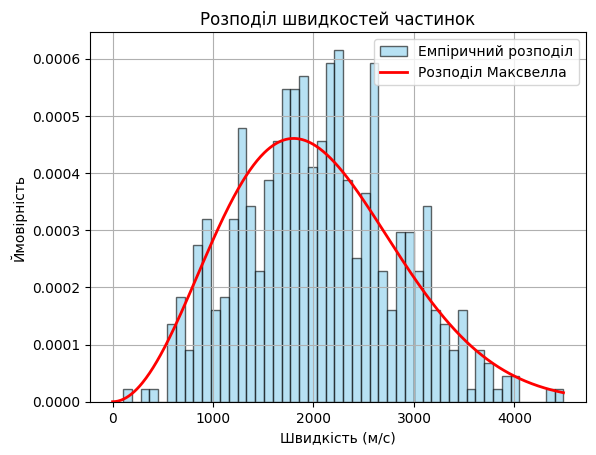

In [ ]:
# Витягуємо всі швидкості з останнього моменту часу
final_velocities = list(velocities.values())[-1]

# Обчислюємо модулі (швидкості)
speeds = [np.linalg.norm(v) for v in final_velocities]

# Побудова гістограми
count, bins, _ = plt.hist(speeds, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Емпіричний розподіл')

# Теоретичний розподіл Максвелла
x = np.linspace(0, max(speeds), 500)

# Обчислення масштабу для розподілу Максвелла
scale = np.sqrt(k * Tdot(T, positions) / M)

# Побудова аналітичної кривої
plt.plot(x, maxwell.pdf(x, scale=scale), 'r-', linewidth=2, label='Розподіл Максвелла')

# Оформлення графіку
plt.title('Розподіл швидкостей частинок')
plt.xlabel('Швидкість (м/с)')
plt.ylabel('Ймовірність')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_63986/1435898407.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P /= np.trapz(P, E)  # нормалізуємо, щоб площа під кривою була 1


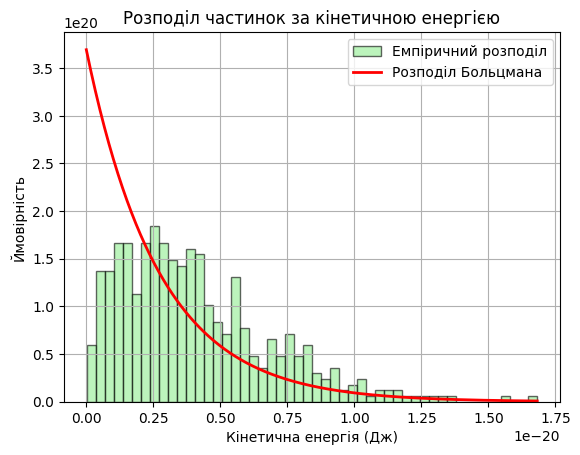

In [ ]:

# Витягуємо всі кінетичні енергії з останнього моменту часу
final_velocities = list(velocities.values())[-1]
energies_sim = [K(np.linalg.norm(v)) for v in final_velocities]  # K(v) вже задана у тебе

# Гістограма енергій
count, bins, _ = plt.hist(energies_sim, bins=50, density=True, alpha=0.6, color='lightgreen', edgecolor='black', label='Емпіричний розподіл')

# Теоретична крива Больцмана
E = np.linspace(0, max(energies_sim), 500)
P = np.exp(-E / (k * Tdot(T, positions)))
P /= np.trapz(P, E)  # нормалізуємо, щоб площа під кривою була 1

# Побудова теоретичної кривої
plt.plot(E, P, 'r-', label='Розподіл Больцмана', linewidth=2)

# Оформлення графіку
plt.title('Розподіл частинок за кінетичною енергією')
plt.xlabel('Кінетична енергія (Дж)')
plt.ylabel('Ймовірність')
plt.legend()
plt.grid(True)
plt.show()

In [1]:
heights = np.linspace(-H / 2, H / 2, number_of_heights)[:len(intervals)]
print(len(heights))
print(heights)
pressures = [mean_pressure(i) for i in intervals]
print(len(pressures))
print(pressures)


# Припустимо, ці параметри задані:
P0 = initial_pressure(N, M, Tdot(T, positions), D, H, k, G)   # початковий тиск (умовна одиниця)

# Висоти
# Теоретичний тиск
P_boltzmann = P0 * np.exp(-(M * G * (heights + H / 2 )  )  / (k * Tdot(T, positions)))

# Побудова графіка
plt.figure(figsize=(8, 5))
plt.plot(heights, pressures, label='Симуляція', marker='o', linestyle='None')
plt.plot(heights, P_boltzmann, label='Больцманівський розподіл', linestyle='-')
plt.xlabel('Висота')
plt.ylabel('Тиск / Густина')
plt.title('Порівняння симульованого та теоретичного розподілу')
plt.legend()
plt.grid(True)
plt.show()
 

NameError: name 'np' is not defined

# Тиск та ізотерми Вандервальса

### Верхня стінка

In [ ]:
p = 

### Нижня стінка

###  Бічна стінка

# Ентропія